In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [4]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop(columns=['Cabin'])

In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
df_encoded = pd.get_dummies(
    df,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

In [8]:
df_encoded = df_encoded.drop(
    columns=['Name', 'Ticket', 'PassengerId']
)

In [9]:
X = df_encoded.drop('Survived', axis=1)

y = df_encoded['Survived']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
y_pred = model.predict(X_test)

In [13]:
original_accuracy = accuracy_score(y_test, y_pred)

print(f"Original Model Accuracy: {original_accuracy:.2%}")

Original Model Accuracy: 81.01%


In [14]:
from sklearn.metrics import classification_report

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



**Why Accuracy Alone Can Be Misleading**

Accuracy tells us how many predictions are correct out of all predictions. However, accuracy can be misleading when the dataset has imbalanced classes. For example, if one class is much larger than another, a model can achieve high accuracy by mostly predicting the larger class while performing poorly on the smaller class. Precision, recall, and F1-score give us a more complete picture of model performance.

In [16]:
original_metrics = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

original_precision = original_metrics["weighted avg"]["precision"]
original_recall = original_metrics["weighted avg"]["recall"]
original_f1 = original_metrics["weighted avg"]["f1-score"]

print(f"Original Accuracy: {original_accuracy:.2%}")
print(f"Original Precision: {original_precision:.2%}")
print(f"Original Recall: {original_recall:.2%}")
print(f"Original F1-Score: {original_f1:.2%}")

Original Accuracy: 81.01%
Original Precision: 80.92%
Original Recall: 81.01%
Original F1-Score: 80.92%


In [17]:
from sklearn.model_selection import GridSearchCV

In [18]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

In [19]:
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [20]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [21]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 1, 'solver': 'liblinear'}


In [22]:
tuned_model = grid_search.best_estimator_

print(tuned_model)

LogisticRegression(C=1, max_iter=1000, solver='liblinear')


In [23]:
LogisticRegression(C=1, max_iter=1000, solver='liblinear')

LogisticRegression(C=1, max_iter=1000, solver='liblinear')

In [24]:
tuned_y_pred = tuned_model.predict(X_test)

In [25]:
print(classification_report(y_test, tuned_y_pred))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [26]:
tuned_accuracy = accuracy_score(y_test, tuned_y_pred)

tuned_metrics = classification_report(
    y_test,
    tuned_y_pred,
    output_dict=True
)

tuned_precision = tuned_metrics["weighted avg"]["precision"]
tuned_recall = tuned_metrics["weighted avg"]["recall"]
tuned_f1 = tuned_metrics["weighted avg"]["f1-score"]

print(f"Tuned Accuracy: {tuned_accuracy:.2%}")
print(f"Tuned Precision: {tuned_precision:.2%}")
print(f"Tuned Recall: {tuned_recall:.2%}")
print(f"Tuned F1-Score: {tuned_f1:.2%}")

Tuned Accuracy: 78.21%
Tuned Precision: 78.08%
Tuned Recall: 78.21%
Tuned F1-Score: 78.02%


In [27]:
# Recalculate original model predictions
original_y_pred = model.predict(X_test)

# Calculate original metrics
original_accuracy = accuracy_score(y_test, original_y_pred)

original_metrics = classification_report(
    y_test,
    original_y_pred,
    output_dict=True
)

original_precision = original_metrics["weighted avg"]["precision"]
original_recall = original_metrics["weighted avg"]["recall"]
original_f1 = original_metrics["weighted avg"]["f1-score"]

print(f"Original Accuracy: {original_accuracy:.2%}")
print(f"Original Precision: {original_precision:.2%}")
print(f"Original Recall: {original_recall:.2%}")
print(f"Original F1-Score: {original_f1:.2%}")

Original Accuracy: 81.01%
Original Precision: 80.92%
Original Recall: 81.01%
Original F1-Score: 80.92%


In [28]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Original Model": [
        original_accuracy,
        original_precision,
        original_recall,
        original_f1
    ],
    "Tuned Model": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

comparison

,Metric,Original Model,Tuned Model
0,Accuracy,0.810056,0.782123
1,Precision,0.809163,0.780815
2,Recall,0.810056,0.782123
3,F1-Score,0.809193,0.780229


In [29]:
comparison_style = comparison.copy()

for col in ["Original Model", "Tuned Model"]:
    comparison_style[col] = comparison_style[col].map(
        lambda x: f"{x:.2%}"
    )

comparison_style

,Metric,Original Model,Tuned Model
0,Accuracy,81.01%,78.21%
1,Precision,80.92%,78.08%
2,Recall,81.01%,78.21%
3,F1-Score,80.92%,78.02%


## Hyperparameter Tuning Results

GridSearchCV was used to tune two Logistic Regression hyperparameters: `C` and `solver`. The best combination found was `C = 1` and `solver = liblinear`.

The original model achieved an accuracy of 81.01% and an F1-score of 80.92%. After hyperparameter tuning, the tuned model achieved an accuracy of 78.21% and an F1-score of 78.02%.

In this experiment, hyperparameter tuning did not improve the model's performance on the test set. This shows that tuning does not always guarantee better results, and model performance should always be evaluated using unseen test data.

In [30]:
from sklearn.metrics import confusion_matrix

tuned_cm = confusion_matrix(y_test, tuned_y_pred)

print("Tuned Model Confusion Matrix:")
print(tuned_cm)

Tuned Model Confusion Matrix:
[[89 16]
 [23 51]]


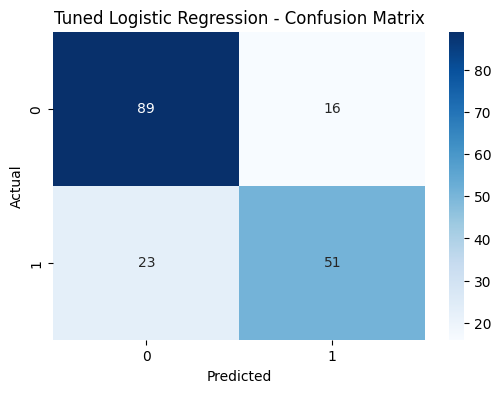

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    tuned_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Logistic Regression - Confusion Matrix")

plt.show()

## Confusion Matrix Explanation

The confusion matrix shows how many passengers were correctly and incorrectly classified as survived or did not survive. The diagonal values represent correct predictions, while the other values represent incorrect predictions. It helps us understand the types of mistakes the model makes instead of only looking at the overall accuracy.

# Task 5 Summary

In this task, I evaluated my Titanic Logistic Regression model using accuracy, precision, recall, and F1-score. I then used GridSearchCV to tune two hyperparameters, `C` and `solver`.

The original model achieved an accuracy of **81.01%** and an F1-score of **80.92%**. The tuned model achieved an accuracy of **78.21%** and an F1-score of **78.02%**.

In this case, the tuned model performed slightly worse than the original model on the test data. This taught me that hyperparameter tuning is a systematic way to search for better settings, but it does not always guarantee an improvement in every dataset or test split.